# Virtual pool screens from pertTF tutorial

You can run this tutorial on Google Colab!  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/179y3UUTXvCHGpmc7lwrOgc8I3svhnD9Z?usp=sharing)



Here we demonstrate the application of pertTF for virtual screens, validated using pooled CRISPR screens.

Here, we perform virtual screens by designating two cell populations (source and target), and rank genes that are most likely to shift populations from source population to target population.

You don't have to train pertTF with lochNESS score. A separate demo will be provided using pertTF trained with lochNESS scores.

## environment setup and importing

In [1]:
!python --version


Python 3.12.12


In [2]:
# Specifically for Google Colab, install dependencies and download data
from google.colab import drive
#drive.mount('/content/drive')

import os
import sys
#%load_ext autoreload
#%autoreload 2

!pip install scanpy flash-attn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 152.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 193.6 MB/s eta 0:00:00
  Created wheel for flash-attn: filename=flash_attn-2.8.3-cp312-cp312-linux_x86_64.whl size=256040057 sha256=f25da18657a87fc83dc1bfb8b7751b82246e9db355510226b674fd437c34b5fb
  Stored in directory: /root/.cache/pip/wheels/3d/59/46/f282c12c73dd4bb3c2e3fe199f1a0d0f8cec06df0cccfeee27
Successfully built flash-attn


In [3]:
import copy
import gc
import json
import os
from pathlib import Path
import sys
import time
import traceback
from typing import List, Tuple, Dict, Union, Optional
import warnings
import random

import torch
from anndata import AnnData
import scanpy as sc
import numpy as np
#import scvi
import wandb
from scipy.sparse import issparse
import matplotlib.pyplot as plt
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

sc.set_figure_params(figsize=(4, 4))
os.environ["KMP_WARNINGS"] = "off"
warnings.filterwarnings('ignore')

## Step 2: new class and function definition (moved to github)


## alternative to Step 2: use pertTF github

In [4]:
# clone main branch
#!git clone https://github.com/davidliwei/pertTF.git
#sys.path.insert(0, '/content/pertTF/')

# use test pyPI
#!pip install -i https://test.pypi.org/simple/ pertTF

# use pypi
!pip install pertTF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 12.6 MB/s eta 0:00:00


In [5]:
#sys.path.insert(0, '/content/pertTF/')

from perttf.model.pertTF import PerturbationTFModel
from perttf.model.config_gen import generate_config
from perttf.model.train_data_gen import produce_training_datasets
from perttf.model.train_function import train,wrapper_train,eval_testdata
from perttf.model.pert_emb import generate_pert_embeddings, calculate_avg_cosine_similarity
from perttf.model.pert_emb import load_pert_embedding_from_gears,load_pert_embedding_to_model
from perttf.utils.preprocessor import Preprocessor
#from perttf.utils


✅ Detected Flash Attention v2.


## load the configuration and the data

Download the previously trained data and model:
https://drive.google.com/file/d/1cqBzXYHHiB3ABiWjrgg5P7GuRDivQqqG/view?usp=sharing

In [6]:
import os

# Install gdown if not already installed
!pip install -q gdown

file_id = '1cqBzXYHHiB3ABiWjrgg5P7GuRDivQqqG'  #
output_filename = 'dev_virtual_screen_training-Oct17-08-57.tar.gz' #

# Construct the download URL
url = f'https://drive.google.com/uc?id={file_id}'

# Download the file using gdown
!gdown --id {file_id} -O {output_filename}

if os.path.exists(output_filename):
    print(f"File '{output_filename}' downloaded successfully!")
else:
    print(f"Failed to download '{output_filename}'. Please check the file ID and permissions.")


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1cqBzXYHHiB3ABiWjrgg5P7GuRDivQqqG
From (redirected): https://drive.google.com/uc?id=1cqBzXYHHiB3ABiWjrgg5P7GuRDivQqqG&confirm=t&uuid=7c0bcf72-9234-49f7-a793-e49db6af970b
To: /content/dev_virtual_screen_training-Oct17-08-57.tar.gz
100% 386M/386M [00:13<00:00, 28.8MB/s]
File 'dev_virtual_screen_training-Oct17-08-57.tar.gz' downloaded successfully!


In [18]:
!tar -xzvf {output_filename}
# Remove .gz and .tar extensions using string replacement
output_filebase = output_filename.replace('.tar.gz', '')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path=Path(f'/content/{output_filebase}') #

dev_virtual_screen_training-Oct17-08-57/
dev_virtual_screen_training-Oct17-08-57/vocab.pt
dev_virtual_screen_training-Oct17-08-57/model_e13.pt
dev_virtual_screen_training-Oct17-08-57/e7_imgs/
dev_virtual_screen_training-Oct17-08-57/e7_imgs/validation_embeddings_genotype_umap_e7.png
dev_virtual_screen_training-Oct17-08-57/e7_imgs/validation_embeddings_batch_umap_e7.png
dev_virtual_screen_training-Oct17-08-57/e7_imgs/validation_embeddings_genotype_next_e7.png
dev_virtual_screen_training-Oct17-08-57/e7_imgs/validation_embeddings_pred_celltype_e7.png
dev_virtual_screen_training-Oct17-08-57/e7_imgs/validation_embeddings_celltype_umap_e7.png
dev_virtual_screen_training-Oct17-08-57/e7_imgs/validation_embeddings_next_umap_celltype_e7.png
dev_virtual_screen_training-Oct17-08-57/e7_imgs/validation_embeddings_next_umap_genotype_e7.png
dev_virtual_screen_training-Oct17-08-57/e7_imgs/validation_embeddings_next_umap_genotype_next_e7.png
dev_virtual_screen_training-Oct17-08-57/e7_imgs/validation_embe

In [ ]:
#adata=sc.read_h5ad(model_path / 'adata_last_validation.h5ad')
#adata=sc.read_h5ad(model_path / 'adata_last_validation_validation.h5ad')
#adata.shape

In [19]:
vocab=torch.load(model_path / 'vocab.pt', weights_only=False)

#genes = adata.var["gene_name"].tolist()

#gene_ids = np.array(vocab(genes), dtype=int)
#gene_ids

In [20]:
# load the running parameters
running_parameters=torch.load(model_path / 'running_parameters.pt', weights_only=False)
running_parameters.keys()

cell_type_to_index = running_parameters['cell_type_to_index']
genotype_to_index = running_parameters['genotype_to_index']
genes = running_parameters['genes']
gene_ids = running_parameters['gene_ids']

n_perturb=len(genotype_to_index)
num_batch_types = 1
n_cls=len(cell_type_to_index)

In [23]:
import json
hyperparameter_lastrun=json.load(open(model_path / 'config.json','r'))

hyperparameter_lastrun['dataset_name']='virtual_screen_validation'
hyperparameter_lastrun

{'seed': 42,
 'gears_path': '/content/drive/MyDrive/Colab Notebooks/scGPT/gears_tutorial/results/gears_gwps-Mar25-03-38/best_model',
 'dataset_name': 'virtual_screen_validation',
 'do_train': True,
 'load_model': None,
 'GEPC': True,
 'ecs_thres': 0.7,
 'dab_weight': 0.0,
 'this_weight': 1.0,
 'next_weight': 1.0,
 'n_rounds': 5,
 'next_cell_pred_type': 'pert',
 'ecs_weight': 1.0,
 'cell_type_classifier': True,
 'cell_type_classifier_weight': 1.0,
 'perturbation_classifier_weight': 1.0,
 'ps_weight': 0.0,
 'perturbation_input': False,
 'CCE': False,
 'mask_ratio': 0.15,
 'epochs': 20,
 'n_bins': 0,
 'lr': 0.001,
 'batch_size': 128,
 'layer_size': 32,
 'nlayers': 2,
 'nhead': 4,
 'dropout': 0.4,
 'schedule_ratio': 0.97,
 'save_eval_interval': 5,
 'log_interval': 100,
 'fast_transformer': True,
 'pre_norm': False,
 'amp': True,
 'do_sample_in_train': False,
 'ADV': False,
 'adv_weight': 10000,
 'adv_E_delay_epochs': 2,
 'adv_D_delay_epochs': 2,
 'lr_ADV': 0.001,
 'DSBN': False,
 'per_seq_

In [24]:
config, run_session = generate_config(hyperparameter_lastrun,wandb_mode="disabled")


wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.


{'seed': 42, 'gears_path': '/content/drive/MyDrive/Colab Notebooks/scGPT/gears_tutorial/results/gears_gwps-Mar25-03-38/best_model', 'dataset_name': 'virtual_screen_validation', 'do_train': True, 'load_model': None, 'GEPC': True, 'ecs_thres': 0.7, 'dab_weight': 0.0, 'this_weight': 1.0, 'next_weight': 1.0, 'n_rounds': 5, 'next_cell_pred_type': 'pert', 'ecs_weight': 1.0, 'cell_type_classifier': True, 'cell_type_classifier_weight': 1.0, 'perturbation_classifier_weight': 1.0, 'ps_weight': 0.0, 'perturbation_input': False, 'CCE': False, 'mask_ratio': 0.15, 'epochs': 20, 'n_bins': 0, 'lr': 0.001, 'batch_size': 128, 'layer_size': 32, 'nlayers': 2, 'nhead': 4, 'dropout': 0.4, 'schedule_ratio': 0.97, 'save_eval_interval': 5, 'log_interval': 100, 'fast_transformer': True, 'pre_norm': False, 'amp': True, 'do_sample_in_train': False, 'ADV': False, 'adv_weight': 10000, 'adv_E_delay_epochs': 2, 'adv_D_delay_epochs': 2, 'lr_ADV': 0.001, 'DSBN': False, 'per_seq_batch_sample': False, 'use_batch_label': 

In [25]:

save_dir = Path(f"./save/dev_{config.dataset_name}-{time.strftime('%b%d-%H-%M')}/")
save_dir.mkdir(parents=True, exist_ok=True)
print(f"save to {save_dir}")

#scg.utils.add_file_handler(scg.logger, save_dir / "run.log")

save to save/dev_virtual_screen_validation-Apr03-15-13


## check the data

In [26]:

def generate_palette(num_colors, cmap_name='viridis'):
    """Generates a color palette with a specified number of colors from a given colormap.

    Args:
        num_colors: The number of colors to generate in the palette.
        cmap_name: The name of the Matplotlib colormap to use (e.g., 'viridis', 'plasma', 'jet').

    Returns:
        A list of RGB tuples representing the color palette.
    """
    cmap = plt.get_cmap(cmap_name)
    palette = [cmap(i) for i in np.linspace(0, 1, num_colors)]
    return palette


## load the model

In [28]:

ntokens = len(vocab)  # size of vocabulary
model = PerturbationTFModel(
    n_perturb, # number of perturbation labels
    3, # layers
    1, # nps
    ntokens,
    config.layer_size, # embsize,
    config.nhead, # nhead,
    config.layer_size, #d_hid,
    config.nlayers, #nlayers,
    vocab=vocab,
    dropout= config.dropout, # config.dropout,
    pad_token=config.pad_token,
    pad_value=config.pad_value,
    do_mvc= config.GEPC, # config.GEPC,
    do_dab=True if config.dab_weight>0 else False, # if config.dab_weight >0 else False,
    use_batch_labels= config.use_batch_label, # config.use_batch_label,
    num_batch_labels=num_batch_types,
    domain_spec_batchnorm= config.DSBN, #config.DSBN,
    n_input_bins= config.n_bins, #n_input_bins,
    ecs_threshold= config.ecs_thres, #config.ecs_thres,
    explicit_zero_prob=config.explicit_zero_prob,
    use_fast_transformer= config.fast_transformer, #config.fast_transformer,
    pre_norm= config.pre_norm, #config.pre_norm,
    n_cls=n_cls, # number of cell type labels
    nlayers_cls=3,
)


In [29]:
#model=torch.load(model_path / 'best_model.pt')
import torch
#model.load_state_dict(torch.load(model_path / 'best_model.pt'))
model.load_state_dict(torch.load(model_path / 'model_e7.pt'),strict=False)
#model.load_state_dict(torch.load(model_path / 'model_e34.pt'))
#model.load_state_dict(torch.load(model_path / 'model_e39.pt'))
#model.load_state_dict(torch.load(model_path / 'model_e54.pt'))
model

PerturbationTFModel(
  (encoder): GeneEncoder(
    (embedding): Embedding(2024, 32, padding_idx=0)
    (enc_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  )
  (value_encoder): ContinuousValueEncoder(
    (dropout): Dropout(p=0.4, inplace=False)
    (linear1): Linear(in_features=1, out_features=32, bias=True)
    (activation): ReLU()
    (linear2): Linear(in_features=32, out_features=32, bias=True)
    (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x FlashTransformerEncoderLayerVarlen(
        (qkv_proj): Linear(in_features=32, out_features=96, bias=True)
        (out_proj): Linear(in_features=32, out_features=32, bias=True)
        (linear1): Linear(in_features=32, out_features=32, bias=True)
        (dropout): Dropout(p=0.4, inplace=False)
        (linear2): Linear(in_features=32, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_aff

In [30]:
# prompt: freeze all parameters in pert_decoder of model for further training

for param in model.pert_decoder.parameters():
  param.requires_grad = False






## use existing model (without fine tuning) and test on PDX1 perturbation data

In [31]:
adata_full=sc.read_h5ad(model_path / 'adata_original_full.h5ad')

In [ ]:

#processed_data_path='/content/drive/MyDrive/Colab Notebooks/scGPT/pancreatic/data/integrated/cleaned/object_integrated_assay3_annotated_nounk_raw.cleaned.h5ad'

#adata0=sc.read_h5ad(processed_data_path)

In [32]:
target_pred_gene='PDX1'

In [33]:
adata_testrun = adata_full[ (adata_full.obs['is_in_training'] == False)
                        & (adata_full.obs['genotype'].isin(['WT',target_pred_gene]))
                        ]
adata_testrun = adata_testrun[adata_testrun.obs['genotype'].isin(genotype_to_index.keys())]
adata_testrun.obs['genotype_next']= adata_testrun.obs['genotype']  # 'PDX1' # set the next predicted
adata_testrun




AnnData object with n_obs × n_vars = 47752 × 2021
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'gene', 'sgrna', 'umi_count', 'nCount_sgRNA', 'nFeature_sgRNA', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'time_point', 'integrated_snn_res.0.5', 'S.Score', 'G2M.Score', 'Phase', 'time', 'celltype', 'celltype_individual', 'celltype_2', 'sub.cluster', 'genotype', 'is_in_training', 'genotype_next'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'var.features', 'var.features.rank', 'vf_vst_counts.8_mean', 'vf_vst_counts.8_variance', 'vf_vst_counts.8_variance.expected', 'vf_vst_counts.8_variance.standardized', 'vf_vst_counts.8_variable', 'vf_vst_counts.8_rank', 'vf_vst_counts.9_mean', 'vf_vst_counts.9_variance', 'vf_vst_counts.9_variance.expected', 'vf_vst_counts.9_variance.standardized', 'vf_vst_counts.9_variable', 'vf_vst_counts.9_rank', 'vf_vst_counts.10_mean', 'vf_vst_counts.10_variance', 'vf_vst_counts.10_variance.e

In [34]:
# for too many WT, do the random sampling
randsel_pdx1=np.random.random(adata_testrun.shape[0])

adata_testrun=adata_testrun[ (~adata_testrun.obs['genotype'].isin(['WT'])) | (randsel_pdx1 < 0.1) ]



In [35]:
adata_testrun.obs.celltype.value_counts()

,count
celltype,
Ductal,2025
PP,1618
EnP,1395
PFG,1163
DE,1001
ESC,991
Liver,250


In [36]:
adata_testrun.obs.genotype.value_counts()

,count
genotype,
WT,4393
PDX1,4050


Here, randomly assigned WT cells to either WT (not perturbed) or PDX1

In [37]:

adata_testrun.obs.loc[adata_testrun.obs['genotype'].isin(['WT']), 'genotype_next'] = np.random.choice([target_pred_gene,'WT'], size = sum(adata_testrun.obs['genotype'].isin(['WT'])))
adata_testrun.obs.loc[adata_testrun.obs['genotype']=='WT' ,'genotype_next'].value_counts()


,count
genotype_next,
WT,2236
PDX1,2157


In [38]:
model.to(device)
eval_results = eval_testdata(model, adata_testrun,gene_ids,
                             train_data_dict={"cell_type_to_index":cell_type_to_index,
                                              "genotype_to_index":genotype_to_index,
                                              "vocab":vocab,},
                             config = config)
eval_results

pertTF - INFO - 2021 genes shared between model vocab's 2024 and anndata's 2021 genes
pertTF - INFO - Evaluating data using 2022 tokens for each cell


100%|██████████| 66/66 [00:11<00:00,  5.99it/s]


AnnData object with n_obs × n_vars = 8443 × 2021
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'gene', 'sgrna', 'umi_count', 'nCount_sgRNA', 'nFeature_sgRNA', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'time_point', 'integrated_snn_res.0.5', 'S.Score', 'G2M.Score', 'Phase', 'time', 'celltype', 'celltype_individual', 'celltype_2', 'sub.cluster', 'genotype', 'is_in_training', 'genotype_next', 'predicted_genotype', 'genotype_id', 'predicted_celltype', 'celltype_id'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'var.features', 'var.features.rank', 'vf_vst_counts.8_mean', 'vf_vst_counts.8_variance', 'vf_vst_counts.8_variance.expected', 'vf_vst_counts.8_variance.standardized', 'vf_vst_counts.8_variable', 'vf_vst_counts.8_rank', 'vf_vst_counts.9_mean', 'vf_vst_counts.9_variance', 'vf_vst_counts.9_variance.expected', 'vf_vst_counts.9_variance.standardized', 'vf_vst_counts.9_variable', 'vf_vst_counts.9_rank', 'vf_vst_c

In [39]:
adata_eva=eval_results #['adata']
adata_eva

AnnData object with n_obs × n_vars = 8443 × 2021
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'gene', 'sgrna', 'umi_count', 'nCount_sgRNA', 'nFeature_sgRNA', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'time_point', 'integrated_snn_res.0.5', 'S.Score', 'G2M.Score', 'Phase', 'time', 'celltype', 'celltype_individual', 'celltype_2', 'sub.cluster', 'genotype', 'is_in_training', 'genotype_next', 'predicted_genotype', 'genotype_id', 'predicted_celltype', 'celltype_id'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'var.features', 'var.features.rank', 'vf_vst_counts.8_mean', 'vf_vst_counts.8_variance', 'vf_vst_counts.8_variance.expected', 'vf_vst_counts.8_variance.standardized', 'vf_vst_counts.8_variable', 'vf_vst_counts.8_rank', 'vf_vst_counts.9_mean', 'vf_vst_counts.9_variance', 'vf_vst_counts.9_variance.expected', 'vf_vst_counts.9_variance.standardized', 'vf_vst_counts.9_variable', 'vf_vst_counts.9_rank', 'vf_vst_c

In [42]:
#sc.pp.neighbors(adata, use_rep="X_scGPT_next")
adata_eva_copy=adata_eva #.copy()
sc.pp.neighbors(adata_eva_copy, use_rep="X_scGPT_next")
sc.tl.umap(adata_eva_copy, min_dist=0.3)

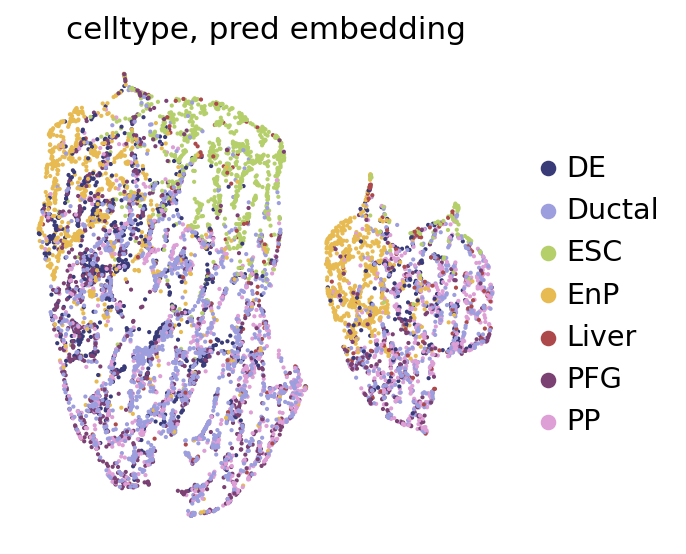

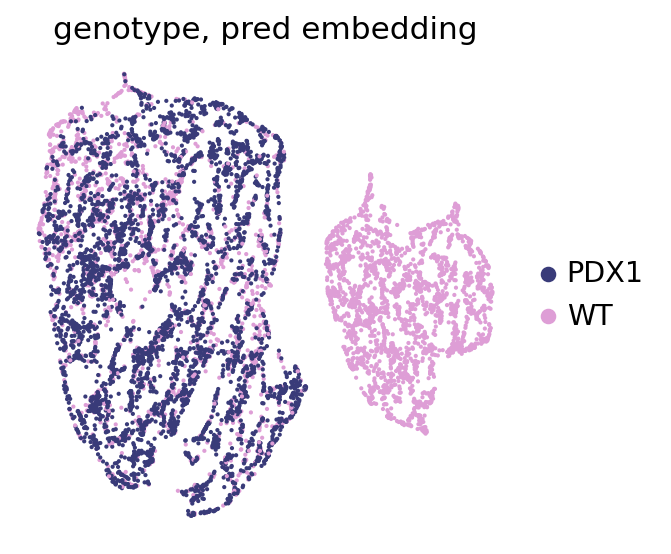

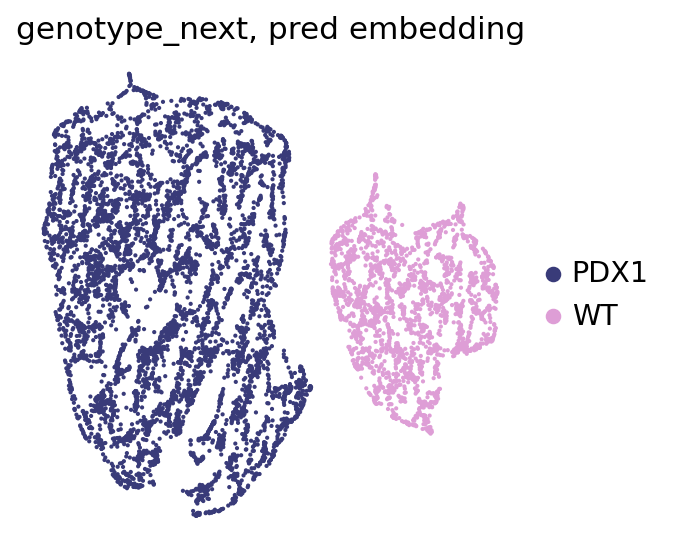

In [43]:
sc.pl.umap(adata_eva_copy, color=["celltype"],
    title=[f"celltype, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
)
sc.pl.umap(adata_eva_copy, color=["genotype"],
    title=[f"genotype, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
)


sc.pl.umap(adata_eva_copy, color=["genotype_next"],
    title=[f"genotype_next, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
)

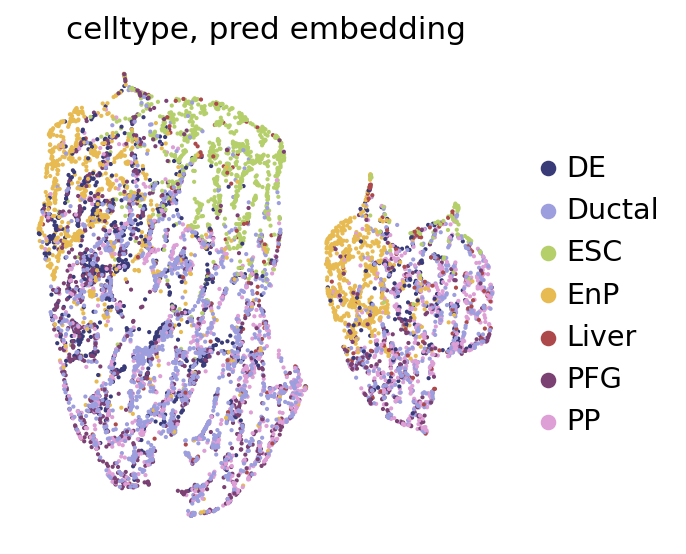

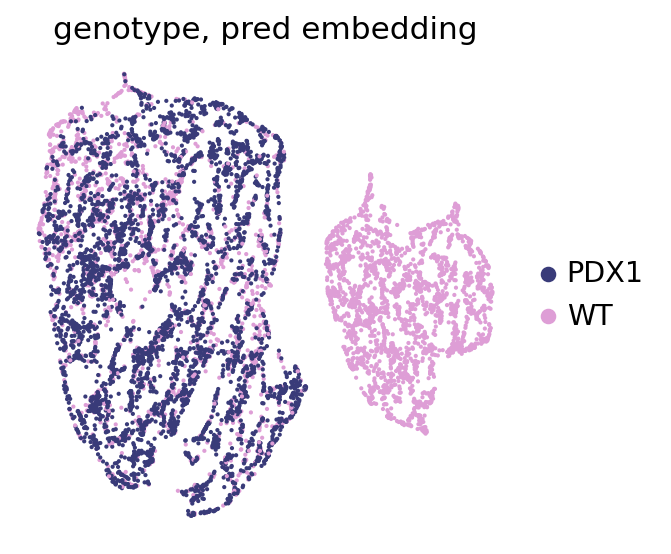

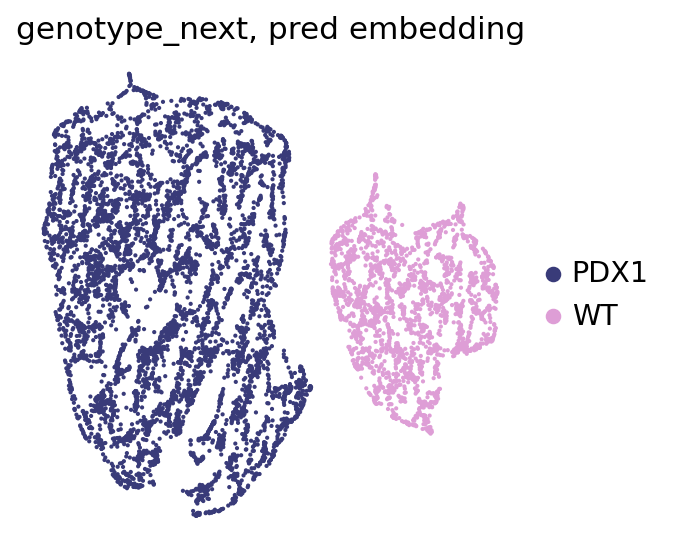

In [44]:
adata_eva_copy2=adata_eva_copy[adata_eva_copy.obs['genotype'].isin(['WT',target_pred_gene])]
adata_eva_copy2
sc.pl.umap(adata_eva_copy2, color=["celltype"],
    title=[f"celltype, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
)
sc.pl.umap(adata_eva_copy2, color=["genotype"],
    title=[f"genotype, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
)


sc.pl.umap(adata_eva_copy2, color=["genotype_next"],
    title=[f"genotype_next, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
)

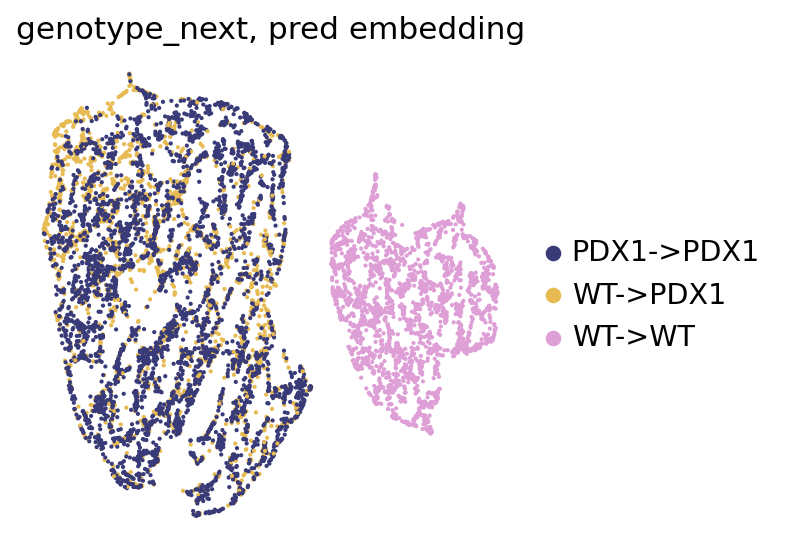

In [45]:
# prompt: concatenate both genotype and genotype_next columns of adata_eva_copy2.obs into a new column named "genotype_combined"

adata_eva_copy2.obs["genotype_combined"] = adata_eva_copy2.obs["genotype"].astype(str) + "->" + adata_eva_copy2.obs["genotype_next"].astype(str)
sc.pl.umap(adata_eva_copy2, color=["genotype_combined"],
    title=[f"genotype_next, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
)

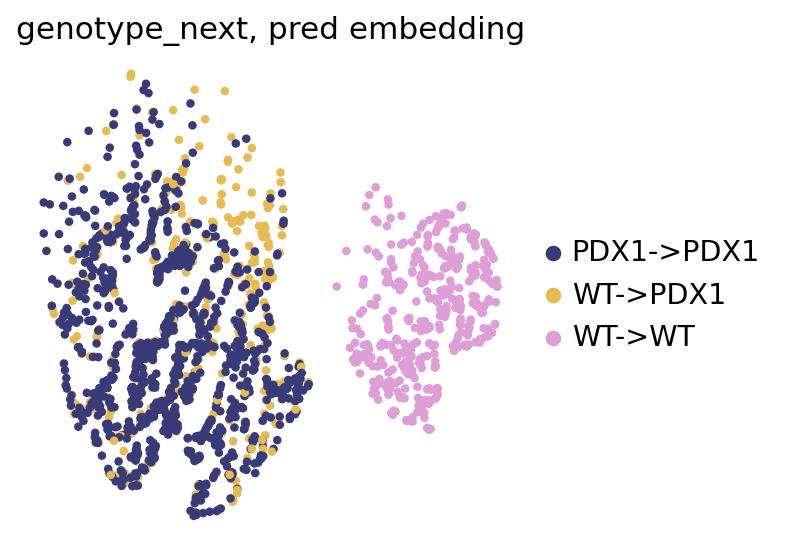

In [46]:
sc.pl.umap(adata_eva_copy2[adata_eva_copy2.obs['celltype'].isin(['Ductal'])], color=["genotype_combined"],
    title=[f"genotype_next, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
)

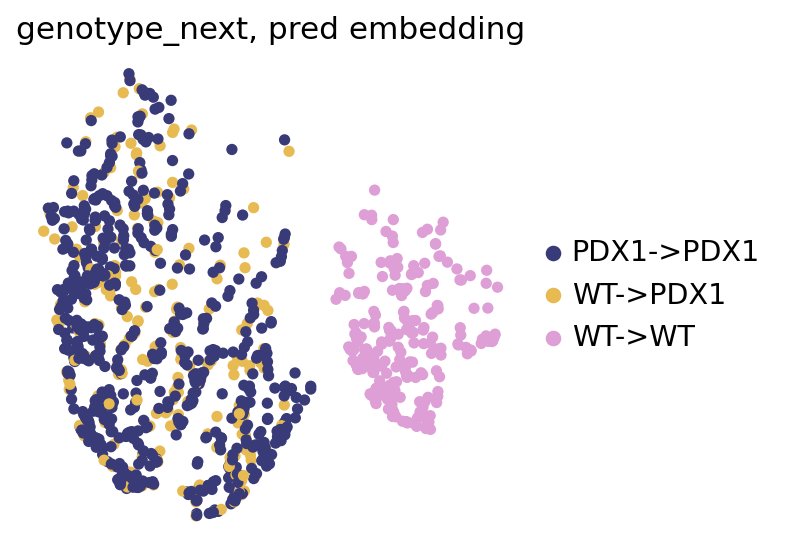

In [47]:
sc.pl.umap(adata_eva_copy2[adata_eva_copy2.obs['celltype'].isin(['PFG'])], color=["genotype_combined"],
    title=[f"genotype_next, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
)

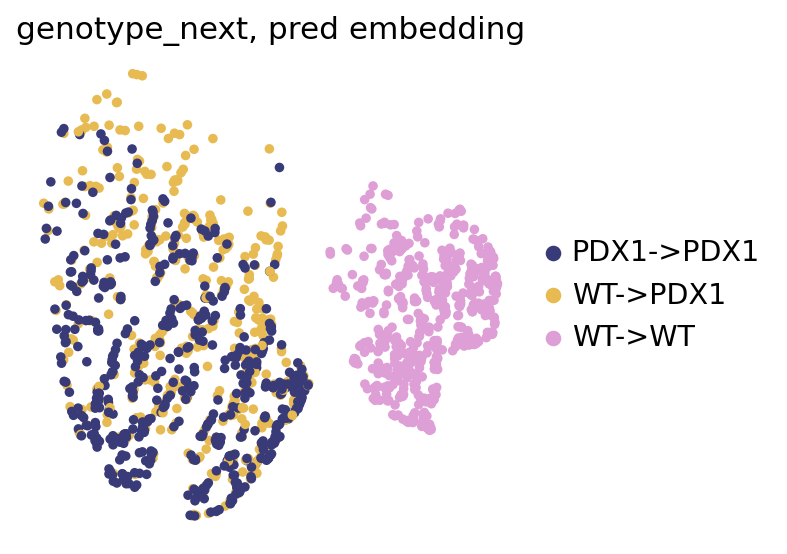

In [48]:
sc.pl.umap(adata_eva_copy2[adata_eva_copy2.obs['celltype'].isin(['PP'])], color=["genotype_combined"],
    title=[f"genotype_next, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
)

## in silico screen: PDX1+ vs PDX1- in PFG and PP

We can simulate which KO affects PDX1 expression



In [49]:
adata_full.obs.celltype.value_counts()

,count
celltype,
PFG,21265
ESC,21205
DE,20972
PP,19544
Ductal,17561
EnP,15699
Liver,5381


In [50]:
adata_full.obs.genotype.value_counts()

,count
genotype,
WT,47513
FOXA1,6731
NKX2-2,4613
MNX1,4602
NEUROD1,4482
FOXA2,4084
PDX1,4050
PAX6,3258
OTUD5,3003


In [51]:
adata_test_gw = adata_full[   (adata_full.obs['genotype'].isin(['WT','PDX1',]))
                        & (adata_full.obs['celltype'].isin(['PFG','PP', ]))
                        & (adata_full.obs['is_in_training'] == False)

                        ]

adata_test_gw = adata_test_gw[~adata_test_gw.obs['orig.ident'].str.endswith('WT')]


#adata_test_gw = adata_test_gw[adata_test_gw.obs['genotype'].isin(genotype_to_index.keys())]
# only keep PDX1 and WT
#adata_test_gw = adata_test_gw[ (adata_test_gw.obs['genotype'].isin(['PDX1','WT'])) & (adata_test_gw.obs['celltype'].isin(['Ductal']))]
#adata_test_gw = adata_test_gw[ (adata_test_gw.obs['genotype'].isin(['PDX1','WT'])) & (adata_test_gw.obs['celltype'].isin(['SC-beta']))]
#adata_test_gw = adata_test_gw[ (adata_test_gw.obs['genotype'].isin(['PDX1','WT'])) & (adata_test_gw.obs['celltype'].isin(['DE']))]


adata_test_gw.obs['genotype_next']= adata_test_gw.obs['genotype']  # 'PDX1' # set the next predicted
adata_test_gw


# for too many WT, do the random sampling
#randsel_pdx1=np.random.random(adata_test_gw.shape[0])

#adata_test_gw=adata_test_gw[ (~adata_test_gw.obs['genotype'].isin(['WT'])) | (randsel_pdx1 < 1) ]



AnnData object with n_obs × n_vars = 3324 × 2021
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'gene', 'sgrna', 'umi_count', 'nCount_sgRNA', 'nFeature_sgRNA', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'time_point', 'integrated_snn_res.0.5', 'S.Score', 'G2M.Score', 'Phase', 'time', 'celltype', 'celltype_individual', 'celltype_2', 'sub.cluster', 'genotype', 'is_in_training', 'genotype_next'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'var.features', 'var.features.rank', 'vf_vst_counts.8_mean', 'vf_vst_counts.8_variance', 'vf_vst_counts.8_variance.expected', 'vf_vst_counts.8_variance.standardized', 'vf_vst_counts.8_variable', 'vf_vst_counts.8_rank', 'vf_vst_counts.9_mean', 'vf_vst_counts.9_variance', 'vf_vst_counts.9_variance.expected', 'vf_vst_counts.9_variance.standardized', 'vf_vst_counts.9_variable', 'vf_vst_counts.9_rank', 'vf_vst_counts.10_mean', 'vf_vst_counts.10_variance', 'vf_vst_counts.10_variance.ex

In [52]:
adata_test_gw.obs.genotype.value_counts()

,count
genotype,
WT,2115
PDX1,1209


In [53]:
#candidate_genes=adata_full.obs.genotype.unique()
#candidate_genes = candidate_genes[candidate_genes.isin(genotype_to_index.keys())]
candidate_genes=genotype_to_index.keys()

len(candidate_genes)

9854

In [54]:
adata_test_gw.obs.genotype.value_counts()
adata_test_gw.obs.celltype.value_counts()


,count
celltype,
PFG,1856
PP,1468


In [55]:
# prompt: set seeds using the current time

import time
import random
import numpy as np
import torch

def set_seeds(seed=None):
  """Sets random seeds for reproducibility. Uses current time if no seed is provided."""
  if seed is None:
    seed = int(time.time())
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

set_seeds() # Call the function to set the seeds


In [56]:

# direct conversion of WT PFG to WT Liver
if True:
  source_pert_label = 'WT' # this is the source of the perturbation. Should be the same as the genotype label of adata_test_wild_type
  dest_pert_label = 'PDX1' # this is the destination of the perturbation. Should be the same as the genotype label of adata_test_wild_type

if False:
  source_pert_label = 'PDX1' # this is the source of the perturbation. Should be the same as the genotype label of adata_test_wild_type
  dest_pert_label = 'WT' # this is the destination of the perturbation. Should be the same as the genotype label of adata_test_wild_type



working_cell_type='PP'
working_cell_type='PFG'


adata_test_gw_base=adata_test_gw[ (adata_test_gw.obs['celltype'].isin([working_cell_type])) & (adata_test_gw.obs['genotype'].isin([source_pert_label])) ]
#adata_test_gw_base=adata_test_gw[adata_test_gw.obs['celltype']=='PP']
adata_test_wild_type = adata_test_gw[ (adata_test_gw.obs['celltype'].isin([working_cell_type])) & (adata_test_gw.obs['genotype'].isin([dest_pert_label])) ]



# conversion of WT PFG to FOXA2 Liver?
#adata_test_gw_base=adata_test_gw[ (adata_test_gw.obs['celltype'].isin(['PFG'])) & (adata_test_gw.obs['genotype'].isin(['WT'])) ]
#adata_test_gw_base=adata_test_gw[adata_test_gw.obs['celltype']=='PP']

#adata_test_wild_type = adata_test_gw[ (adata_test_gw.obs['celltype'].isin(['Liver'])) & (adata_test_gw.obs['genotype'].isin(['FOXA2'])) ]


In [57]:
adata_test_gw.var

,vst.mean,vst.variance,vst.variance.expected,vst.variance.standardized,vst.variable,var.features,var.features.rank,vf_vst_counts.8_mean,vf_vst_counts.8_variance,vf_vst_counts.8_variance.expected,...,vf_vst_counts.13_variance.standardized,vf_vst_counts.13_variable,vf_vst_counts.13_rank,vf_vst_counts.14_mean,vf_vst_counts.14_variance,vf_vst_counts.14_variance.expected,vf_vst_counts.14_variance.standardized,vf_vst_counts.14_variable,vf_vst_counts.14_rank,highly_variable
NPPB,0.121144,3.858692,0.144001,18.163974,1,NPPB,523,0.003035,0.004291,0.003127,...,2.605360,1,720,0.005650,0.029461,0.006367,2.753968,1,523,True
KAZN,1.386999,6.554509,2.535651,2.584941,1,KAZN,1014,1.103819,2.011100,1.442363,...,2.076502,1,1173,1.000452,3.685519,1.809286,2.037001,1,1014,True
HSPG2,0.063707,0.216914,0.076726,2.827142,1,NA,-2147483648,0.199671,0.215217,0.216702,...,1.473857,0,-2147483648,0.279774,0.524355,0.369411,1.419436,0,-2147483648,True
CELA3A,0.006414,0.021364,0.007287,2.931820,1,CELA3A,102,0.000000,0.000000,0.000000,...,7.680171,1,76,0.029266,0.257350,0.035724,5.801917,1,102,True
ID3,0.105146,0.399682,0.125686,3.180015,1,ID3,905,2.179439,4.710557,3.348997,...,2.427566,1,841,0.503898,1.576402,0.736048,2.141711,1,905,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PCDH11Y,0.026160,0.049262,0.031474,1.565167,1,PCDH11Y,1040,0.286545,0.455886,0.317412,...,2.312744,1,940,0.143107,0.363891,0.180793,2.012756,1,1040,True
TTTY14,0.534088,0.847198,0.698779,1.212399,0,TTTY14,1440,1.096485,1.616970,1.430941,...,1.743535,1,1714,1.248644,4.322884,2.505117,1.725621,1,1440,True
MT-CO2,77.294826,2357.401144,6216.206797,0.379235,0,NA,-2147483648,105.829160,1925.048969,1617.679969,...,0.591713,0,-2147483648,83.118644,2990.640988,4989.195876,0.599423,0,-2147483648,True
MT-CO3,24.605290,252.571039,468.961868,0.538575,0,NA,-2147483648,75.549949,1154.458236,863.383135,...,0.583089,0,-2147483648,40.019831,653.998985,1107.931910,0.590288,0,-2147483648,True


In [ ]:
#sc.pl.umap(adata_test_gw_base, color=["PDX1"])

In [58]:
adata_test=adata_full[adata_full.obs['orig.ident']=='Sample_L_2_3DEC']
adata_test.obs['genotype'].value_counts()

,count
genotype,
PDX1,786
WT,707
NKX6-1,415
MNX1,414
PROSER1,396
FOXA1,358
NEUROD1,349
NKX2-2,314
RFX6,262


In [59]:
adata_full.obs[['orig.ident','genotype']].value_counts()
adata_full.obs[['orig.ident',]].value_counts()


,count
orig.ident,
Sample_H_DE,18739
Sample_I_PFG,18463
Sample_G_2_ESC,11250
Sample_J_PP,11161
Sample_D_WT,8555
Sample_F_WT,7604
Sample_G_1_ESC,7513
Sample_E_WT,7295
Sample_B_WT,6573


In [60]:
adata_test_gw_base.obs[['orig.ident','genotype']].value_counts()


,,count
orig.ident,genotype,
Sample_I_PFG,WT,983
Sample_J_PP,WT,81
Sample_L_2_3DEC,WT,69
Sample_L_1_3DEC,WT,53
Sample_H_DE,WT,1


In [61]:
adata_test_wild_type.n_obs
adata_test_gw_base.n_obs

1187

The following code is to fix a bug from the current pertTF PyPI and test PyPI version (0.1.1) of generate_pert_embedding function. Will fix it on github and the next version

In [63]:


def generate_pert_embeddings(adata_target, adata_wt, candidate_genes,
                             model, gene_ids, cell_type_to_index, genotype_to_index, vocab,
                             config, device,
                             n_expands_per_epoch = 50,
                             n_epoch = 4,
                             wt_pred_next_label = "WT", ):
    """
    Generate perturbation embeddings for target cells, and calculate cosine similarity between all target cells vs wild-type cells

    Args:
      adata_target: AnnData object of the target cells, where the perturbation will be based on (this is the "source" of the perturbation).
      adata_wt: AnnData object of the wildtype cells. This is considered as the "target" of the perturbation
      candidate_genes: List of candidate genes for perturbation.
      model:
      gene_ids:
      cell_type_to_index:
      genotype_to_index:
      vocab:
      config:
      device:
      n_expands_per_epoch: the number of duplicates in adata_target to be used for perturbation simulation. For smaller number of target cells, set it to a big number
      n_epoch:  the number of rounds that perturbaiton prediction is performed
      wt_pred_next_label: This should fill the "pred_next" label for adata_wt. Default WT
    Returns:
      cell_emb_data_all: generated cell embeddings, a 2-d np array. Row size: (adata_target.n_obs*n_expands_per_epoch + adata_wt.n_obs)*n_epoch. Column size: (emb_size of the model)
      perturb_info_all: a Pandas dataframe describing the cell information in cell_emb_data_all
      cs_matrix_res: cosine similarity matrix, a 2-d np array. Size: adata_wt.n_obs * (adata_target.n_obs*n_expands_per_epoch) * n_epoch
      a_eva: evaluated AnnData object from the last round of evaluation
    """
    # expand
    adata_bwmerge=sc.concat([adata_target]*n_expands_per_epoch + [adata_wt],axis=0)
    cell_emb_data_all = None
    perturb_info_all = None

    cs_matrix_res = np.zeros((adata_wt.shape[0], adata_target.shape[0] * n_expands_per_epoch, n_epoch))
    # loop over epochs
    for n_round in range(n_epoch):
        # assign genoytpe_next
        gt_next_1 = np.random.choice(list(candidate_genes), size = adata_target.shape[0] * n_expands_per_epoch)
        #adata_test_gw_wtmerge.obs.loc[adata_test_gw_wtmerge.obs['genotype']=='WT' ,'genotype_next'].value_counts()
        gt_next_2 = [wt_pred_next_label]*adata_wt.shape[0]
        gt_next = np.concatenate([gt_next_1,gt_next_2])
        adata_bwmerge.obs[ 'genotype_next'] = gt_next

        # feed into model
        model.to(device)
        eval_results_0 = eval_testdata(model, adata_bwmerge, gene_ids,
                                    train_data_dict={"cell_type_to_index":cell_type_to_index,
                                                      "genotype_to_index":genotype_to_index,
                                                      "vocab":vocab,},
                                    config = config,
                                    make_plots=False)
        #
        a_eva=eval_results_0#['adata']
        cell_emb_data=a_eva.obsm['X_scGPT_next'] #[:10000,:]
        perturb_info=a_eva.obs[['genotype','genotype_next']]

        perturb_info['round']=n_round
        perturb_info['type']=['pert_source']*adata_target.shape[0]*n_expands_per_epoch + ['pert_dest']*adata_wt.shape[0]

        # calculate cosine similarity
        from sklearn.metrics.pairwise import cosine_similarity

        # Calculate cosine similarity
        #adata_eva_copy_othergenes
        cell_emb_data_treat = cell_emb_data[perturb_info['type']=='pert_source']

        cell_emb_data_ref = cell_emb_data[perturb_info['type']=='pert_dest']
        # Calculate cosine similarity
        cosine_sim_matrix = cosine_similarity(cell_emb_data_ref, cell_emb_data_treat)
        cs_matrix_res[:,:,n_round] = cosine_sim_matrix
        if cell_emb_data_all is None:
            cell_emb_data_all = cell_emb_data
            perturb_info_all = perturb_info

        else:
            cell_emb_data_all = np.concatenate([cell_emb_data_all, cell_emb_data], axis=0)
            perturb_info_all = pd.concat([perturb_info_all, perturb_info], axis=0)

    perturb_info_all.reset_index(inplace=True)
    return cell_emb_data_all, perturb_info_all, cs_matrix_res, a_eva


In [64]:
import pandas as pd

cell_emb_all, perturb_f_all, cs_mat_res, adata_last_eva = generate_pert_embeddings(adata_test_gw_base,
                                                                       adata_test_wild_type,
                                                                       candidate_genes,
                                                                       model, gene_ids, cell_type_to_index, genotype_to_index, vocab, config, device,
                                                                       n_expands_per_epoch= 40,
                                                                       n_epoch= 20,
                                                                       wt_pred_next_label =   dest_pert_label,  )







pertTF - INFO - 2021 genes shared between model vocab's 2024 and anndata's 2021 genes
pertTF - INFO - Evaluating data using 2022 tokens for each cell


100%|██████████| 377/377 [00:10<00:00, 37.08it/s]


pertTF - INFO - 2021 genes shared between model vocab's 2024 and anndata's 2021 genes
pertTF - INFO - Evaluating data using 2022 tokens for each cell


100%|██████████| 377/377 [00:12<00:00, 29.97it/s]


pertTF - INFO - 2021 genes shared between model vocab's 2024 and anndata's 2021 genes
pertTF - INFO - Evaluating data using 2022 tokens for each cell


...

100%|██████████| 377/377 [00:10<00:00, 36.66it/s]


pertTF - INFO - 2021 genes shared between model vocab's 2024 and anndata's 2021 genes
pertTF - INFO - Evaluating data using 2022 tokens for each cell


100%|██████████| 377/377 [00:10<00:00, 37.15it/s]


pertTF - INFO - 2021 genes shared between model vocab's 2024 and anndata's 2021 genes
pertTF - INFO - Evaluating data using 2022 tokens for each cell


100%|██████████| 377/377 [00:10<00:00, 36.97it/s]


In [65]:
cell_emb_all.shape
perturb_f_all
cs_mat_res.shape

(669, 47480, 20)

In [66]:
tx1=perturb_f_all[(perturb_f_all['round'] == 0) & (perturb_f_all['type']=='pert_dest') ]
tx2=perturb_f_all[(perturb_f_all['round'] == 1) & (perturb_f_all['type']=='pert_dest') ]
tx1


,index,genotype,genotype_next,round,type
47480,AAACCCATCCTTACCG-1_11,PDX1,PDX1,0,pert_dest
47481,AAACGCTAGGTAAACT-1_11,PDX1,PDX1,0,pert_dest
47482,AAAGGATGTGTCTTAG-1_11,PDX1,PDX1,0,pert_dest
47483,AAAGTCCTCCCGAGTG-1_11,PDX1,PDX1,0,pert_dest
47484,AACAAAGAGAGGATCC-1_11,PDX1,PDX1,0,pert_dest
...,...,...,...,...,...
48144,TCGGGCATCACCATGA-1_14,PDX1,PDX1,0,pert_dest
48145,TCTCCGATCTTACACT-1_14,PDX1,PDX1,0,pert_dest
48146,TGATTCTGTGCAACAG-1_14,PDX1,PDX1,0,pert_dest
48147,TGTCAGATCAGAACCT-1_14,PDX1,PDX1,0,pert_dest


In [ ]:
#perturb_f_all.loc['EC1_AAAGTCCTCCCTTTGG-1']

In [67]:
#perturb_f_all.reset_index(inplace=True)
perturb_f_all

,index,genotype,genotype_next,round,type
0,AGCGTATCATGCAGCC-1_10,WT,MOB1B,0,pert_source
1,AAACGAAAGACGCATG-1_11,WT,FTSJ3,0,pert_source
2,AAACGAAAGTCTAGAA-1_11,WT,ATP6V0A1,0,pert_source
3,AAACGAAGTTATCTTC-1_11,WT,OSTC,0,pert_source
4,AAACGCTGTTGCACGC-1_11,WT,RNASEH1,0,pert_source
...,...,...,...,...,...
962975,TCGGGCATCACCATGA-1_14,PDX1,PDX1,19,pert_dest
962976,TCTCCGATCTTACACT-1_14,PDX1,PDX1,19,pert_dest
962977,TGATTCTGTGCAACAG-1_14,PDX1,PDX1,19,pert_dest
962978,TGTCAGATCAGAACCT-1_14,PDX1,PDX1,19,pert_dest


In [ ]:
# prompt: get the row number of round equal to 0 in perturb_f_all

# Assuming 'perturb_f_all' is a pandas DataFrame as shown in the provided code.

# Find the row numbers where 'round' is equal to 0.
#rows_with_round_zero = perturb_f_all[ perturb_f_all['type'] == 'wildtype'].index

# Print the row numbers.
#rows_with_round_zero.to_list()


In [68]:
cs_mat_res[:,:,0]
cs_mat_res.shape

(669, 47480, 20)

In [ ]:

def calculate_avg_cosine_similarity(input_mat,pd_pert_f):
    """
    Calculate average cosine similarity from a given cosine similarity matrix of size (n_ctrl,n_cell,n_round),
     and a pandas dataframe pd_pert_tf of size (nctrl+n_cell)*n_round
    """
    n_ctrl=input_mat.shape[0]
    n_cell=input_mat.shape[1]
    n_round=input_mat.shape[2]
    assert( (n_ctrl + n_cell)* n_round == pd_pert_f.shape[0])
    # Calculate mean cosine similarity
    #cs_nx1 = np.sum(input_mat, axis=0)/input_mat.shape[0]
    # median
    #cs_nx1 = np.median(input_mat, axis=0)
    # percentile
    cs_nx1 = np.percentile(input_mat, 90, axis=0)
    #print(cs_nx1.shape)

    # prompt: convert cs_nx1 to a 1-dimension array

    cs_nx1_1d = cs_nx1.flatten('F')

    perturb_f_p=pd_pert_f[ pd_pert_f['type'] == 'pert_source']
    perturb_f_p.shape

    perturb_f_p['cosine_sim_matrix_column_avg'] = cs_nx1_1d
    perturb_f_p.reset_index(inplace=True)
    return perturb_f_p


In [69]:
perturb_f_p = calculate_avg_cosine_similarity(cs_mat_res, perturb_f_all)

Rank genes based on the average value of cosine similarity

In [71]:
perturb_f_p

,level_0,index,genotype,genotype_next,round,type,cosine_sim_matrix_column_avg
0,0,AGCGTATCATGCAGCC-1_10,WT,MOB1B,0,pert_source,0.990928
1,1,AAACGAAAGACGCATG-1_11,WT,FTSJ3,0,pert_source,0.993721
2,2,AAACGAAAGTCTAGAA-1_11,WT,ATP6V0A1,0,pert_source,0.992391
3,3,AAACGAAGTTATCTTC-1_11,WT,OSTC,0,pert_source,0.990644
4,4,AAACGCTGTTGCACGC-1_11,WT,RNASEH1,0,pert_source,0.995127
...,...,...,...,...,...,...,...
949595,962306,TGCTTCGCACGGCCAT-1_14,WT,CYTH2,19,pert_source,0.988922
949596,962307,TGTAAGCAGGTACAGC-1_14,WT,UBE2O,19,pert_source,0.994115
949597,962308,TGTGCGGAGAAGGCTC-1_14,WT,SEPTIN5,19,pert_source,0.990960
949598,962309,TTCATTGAGCTGTTAC-1_14,WT,LAMP2,19,pert_source,0.992599


In [72]:


average_cosine_similarity = perturb_f_p.groupby('genotype_next')['cosine_sim_matrix_column_avg'].agg(
    mean='mean',
    median='median',
    count='count',
    percentile_90=lambda x: np.percentile(x, 90),)

# Sort the result
sorted_average_cosine_similarity = average_cosine_similarity.sort_values(by='mean',ascending=False)

# Add ranking
sorted_average_cosine_similarity = sorted_average_cosine_similarity.reset_index()
sorted_average_cosine_similarity['rank'] = sorted_average_cosine_similarity['mean'].rank(ascending=False, method='dense')
sorted_average_cosine_similarity['rank_median'] = sorted_average_cosine_similarity['median'].rank(ascending=False, method='dense')
sorted_average_cosine_similarity['rank_percentile90'] = sorted_average_cosine_similarity['percentile_90'].rank(ascending=False, method='dense')

sorted_average_cosine_similarity.set_index('genotype_next', inplace=True)
sorted_average_cosine_similarity = sorted_average_cosine_similarity.sort_values(by='percentile_90',ascending=False)
sorted_average_cosine_similarity

,mean,median,count,percentile_90,rank,rank_median,rank_percentile90
genotype_next,,,,,,,
PDX1,0.999996,0.999997,105,0.999998,1.0,1.0,1.0
LLPH,0.999020,0.999017,119,0.999039,2.0,2.0,2.0
FOXP3,0.998866,0.998864,89,0.998898,3.0,3.0,3.0
CLK3,0.998685,0.998677,101,0.998744,4.0,4.0,4.0
CRNKL1,0.998656,0.998649,108,0.998694,5.0,5.0,5.0
...,...,...,...,...,...,...,...
PINX1,0.970328,0.970322,97,0.970409,9850.0,9850.0,9850.0
ZFP36L2,0.969670,0.969682,84,0.969768,9851.0,9851.0,9851.0
PPA1,0.969319,0.969325,97,0.969419,9852.0,9852.0,9852.0


In [ ]:
#cs_nx1.shape

In [73]:
np.sum(cs_mat_res[:,:,0], axis=0)/cs_mat_res.shape[0]

array([0.99092846, 0.9937212 , 0.99239059, ..., 0.99290487, 0.99150794,
       0.98689217])

In [75]:
sorted_average_cosine_similarity.loc['PDX1']


,PDX1
mean,0.999996
median,0.999997
count,105.000000
percentile_90,0.999998
rank,1.000000
rank_median,1.000000
rank_percentile90,1.000000


In [76]:
# prompt: write the pandas dataframe sorted_average_cosine_similarity to a txt file

sorted_average_cosine_similarity.to_csv('sorted_average_cosine_similarity.txt', sep='\t')


In [77]:
sorted_average_cosine_similarity['percentile_90'].max()

0.9999981421348048

In [78]:
sorted_average_cosine_similarity['plot_score'] = -1*np.log10(1-sorted_average_cosine_similarity['percentile_90'])

# plot the -log10 of plot_score



<Axes: xlabel='genotype_next'>

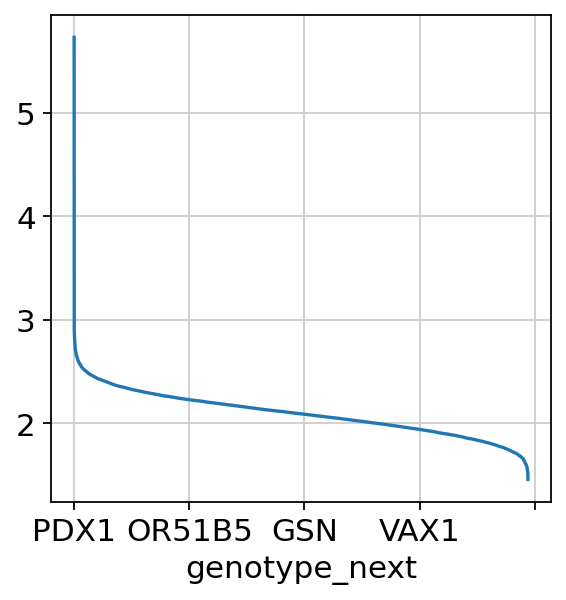

In [79]:
sorted_average_cosine_similarity['plot_score'].plot(kind='line',xticks=None)

In [80]:
sorted_average_cosine_similarity

,mean,median,count,percentile_90,rank,rank_median,rank_percentile90,plot_score
genotype_next,,,,,,,,
PDX1,0.999996,0.999997,105,0.999998,1.0,1.0,1.0,5.730986
LLPH,0.999020,0.999017,119,0.999039,2.0,2.0,2.0,3.017213
FOXP3,0.998866,0.998864,89,0.998898,3.0,3.0,3.0,2.957862
CLK3,0.998685,0.998677,101,0.998744,4.0,4.0,4.0,2.901037
CRNKL1,0.998656,0.998649,108,0.998694,5.0,5.0,5.0,2.884116
...,...,...,...,...,...,...,...,...
PINX1,0.970328,0.970322,97,0.970409,9850.0,9850.0,9850.0,1.528839
ZFP36L2,0.969670,0.969682,84,0.969768,9851.0,9851.0,9851.0,1.519533
PPA1,0.969319,0.969325,97,0.969419,9852.0,9852.0,9852.0,1.514555


### use pooled screens as independent validations

In [81]:
pool_screen_pos_list=["NF2","CCDC6","EOMES","SPOP","UBE2M","MAPK1","RARA","PTEN","TCEB3","GATA4","METTL3","FBXO42","GATA6","MIXL1","SMAD2","ACVR1B","TGFBR1","PDX1","CARM1","PIGT","BMPR1A","CDK8","HHEX","CCNC","ISL1","FOXO1","ZSWIM6","DDX3X","SOX17","ZMYM2","FGFR2","ABCC9","YY1","MED12","MSL1","RCOR2","RNF111","KCTD10","WDR83","GPI","POU2F1","XPO7","ZC3H13","IQCH","GPR110","CREBBP","CDK13","ZSWIM4","SNAI1"]
pool_screen_neg_list=["L1TD1","NOTCH4","HN1L","PTBP3","IZUMO2","CA8","GCG","GP1BB","SAT1","CDC42BPA","RNASE13","FBXO7","NGEF","NECAB1","PRR23C","PDCL2","DIAPH2","KIAA1210","TRIM38","NAT6","FBXL15","WWC3","NOL4","TMEM200B","HMHA1","STARD8","CAPNS1","TAPT1","ETS1","DPF1","TYW1B","ARL6","LEO1","ST7","DDAH2","MAGEB10","HLTF","GJD4","C17orf97","ABCF3","PAFAH2","FAM149B1","CCDC82","SSX4","BTG2","CALCOCO2","DIDO1","ATP6V1C2","ZBTB7C"]

In [ ]:
#pool_screen_top.index('TRRAP')
#1-ranks/np.max(ranks)

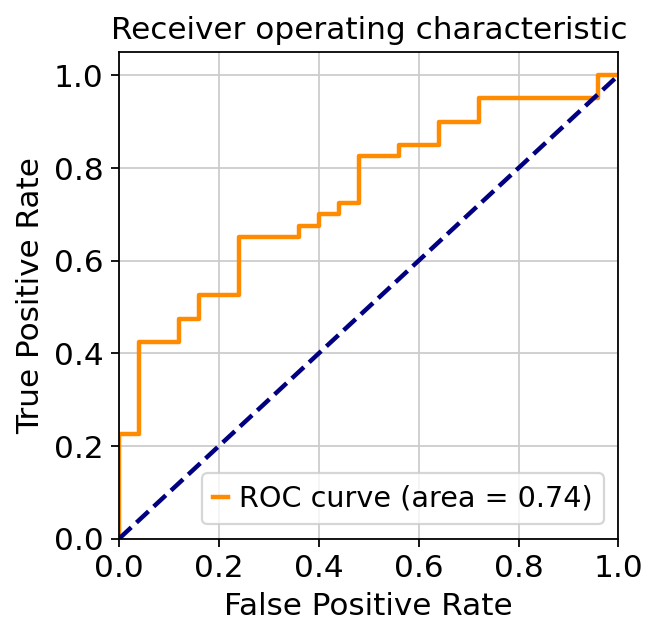

In [82]:
# prompt: calculate and plot AUROC curve using the rank column of sorted_average_cosine_similarity, with positive samples defined in pool_screen_pos_list, and negative samples defined in pool_screen_neg_list

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assuming 'sorted_average_cosine_similarity', 'pool_screen_pos_list', and 'pool_screen_neg_list' are defined as in the previous code.

subset_fr=sorted_average_cosine_similarity.loc[sorted_average_cosine_similarity.index.isin(pool_screen_pos_list+pool_screen_neg_list)]
#subset_fr
# Extract ranks and create binary labels
#ranks = subset_fr['rank'].values

ranks = subset_fr['rank_percentile90'].values
y_true = subset_fr.index.isin(pool_screen_pos_list).astype(int)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, 1-ranks/np.max(ranks)) # Invert ranks for descending order
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()


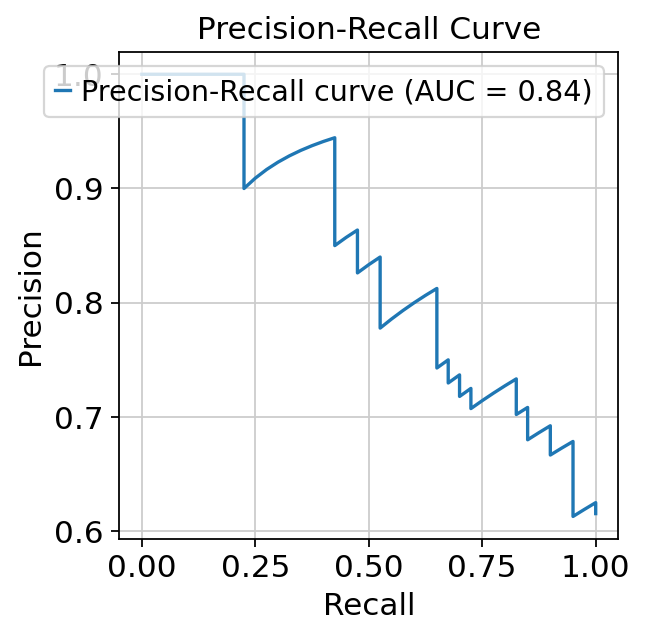

In [84]:
# prompt: calculate and plot AUROC curve using the rank column of sorted_average_cosine_similarity, with positive samples defined in pool_screen_pos_list, and negative samples defined in pool_screen_neg_list

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve

# Assuming 'sorted_average_cosine_similarity', 'pool_screen_pos_list', and 'pool_screen_neg_list' are defined as in the previous code.

subset_fr=sorted_average_cosine_similarity.loc[sorted_average_cosine_similarity.index.isin(pool_screen_pos_list+pool_screen_neg_list)]
#subset_fr
# Extract ranks and create binary labels
#ranks = subset_fr['rank'].values

ranks = subset_fr['rank_percentile90'].values
y_true = subset_fr.index.isin(pool_screen_pos_list).astype(int)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, 1-ranks/np.max(ranks)) # Invert ranks for descending order
roc_auc = auc(fpr, tpr)



precision, recall, thresholds = precision_recall_curve(y_true, 1-ranks/np.max(ranks))  # Invert ranks for descending order

# Calculate AUC
pr_auc = auc(recall, precision)

# Plot the precision-recall curve
plt.plot(recall, precision, label=f'Precision-Recall curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='upper right')
plt.show()


### checking gene expression

Note that since we are only using a subset of genes, the AUC curve may be different from what is reported in the paper.

In [85]:
#adata0_sel_raw=adata0[adata0.obs_names.isin(adata_test_gw_base.obs_names),:]
#adata0_sel_raw=adata0[adata0.obs.celltype.isin(adata_test_gw_base.obs.celltype),:]

#adata0_sel_raw=adata0 #[adata0.obs.celltype.isin(adata_test_gw_base.obs.celltype),:]
adata0_sel_raw = adata_full
adata0_sel_raw

AnnData object with n_obs × n_vars = 121627 × 2021
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'gene', 'sgrna', 'umi_count', 'nCount_sgRNA', 'nFeature_sgRNA', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'time_point', 'integrated_snn_res.0.5', 'S.Score', 'G2M.Score', 'Phase', 'time', 'celltype', 'celltype_individual', 'celltype_2', 'sub.cluster', 'genotype', 'is_in_training'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'var.features', 'var.features.rank', 'vf_vst_counts.8_mean', 'vf_vst_counts.8_variance', 'vf_vst_counts.8_variance.expected', 'vf_vst_counts.8_variance.standardized', 'vf_vst_counts.8_variable', 'vf_vst_counts.8_rank', 'vf_vst_counts.9_mean', 'vf_vst_counts.9_variance', 'vf_vst_counts.9_variance.expected', 'vf_vst_counts.9_variance.standardized', 'vf_vst_counts.9_variable', 'vf_vst_counts.9_rank', 'vf_vst_counts.10_mean', 'vf_vst_counts.10_variance', 'vf_vst_counts.10_variance.expected', 'vf_vs

In [87]:
adata0_sel_raw.var_names

Index(['NPPB', 'KAZN', 'HSPG2', 'CELA3A', 'ID3', 'SFN', 'IFI6', 'MATN1',
       'FABP3', 'LINC01226',
       ...
       'MAMLD1', 'MAGEA4', 'BGN', 'LINC00278', 'AC012078.2', 'PCDH11Y',
       'TTTY14', 'MT-CO2', 'MT-CO3', 'MT-CYB'],
      dtype='object', length=2021)

In [89]:
subset_fr_2=subset_fr[subset_fr.index.isin(adata0_sel_raw.var_names)]


In [90]:
raw_exp_matrix=adata0_sel_raw[:,subset_fr_2.index].X
mat_ar=raw_exp_matrix.toarray()
subset_fr_2['exp_mean']=np.mean(mat_ar, axis=0)
subset_fr_2

,mean,median,count,percentile_90,rank,rank_median,rank_percentile90,plot_score,exp_mean
genotype_next,,,,,,,,,
PDX1,0.999996,0.999997,105,0.999998,1.0,1.0,1.0,5.730986,0.264706
GATA6,0.996624,0.996625,104,0.996671,330.0,328.0,330.0,2.477730,0.559126
GATA4,0.995973,0.995971,85,0.996006,701.0,703.0,708.0,2.398616,0.951274
HHEX,0.993192,0.993196,80,0.993251,3480.0,3477.0,3475.0,2.170744,0.275312
ETS1,0.990064,0.990064,98,0.990108,6466.0,6465.0,6480.0,2.004708,0.102200
ISL1,0.989956,0.989954,99,0.990028,6545.0,6546.0,6540.0,2.001197,0.080697
SOX17,0.989716,0.989713,94,0.989739,6725.0,6728.0,6753.0,1.988816,0.187227
FOXO1,0.987615,0.987610,103,0.987678,7915.0,7917.0,7918.0,1.909333,0.387883
SAT1,0.986465,0.986466,90,0.986528,8396.0,8396.0,8400.0,1.870564,0.620443


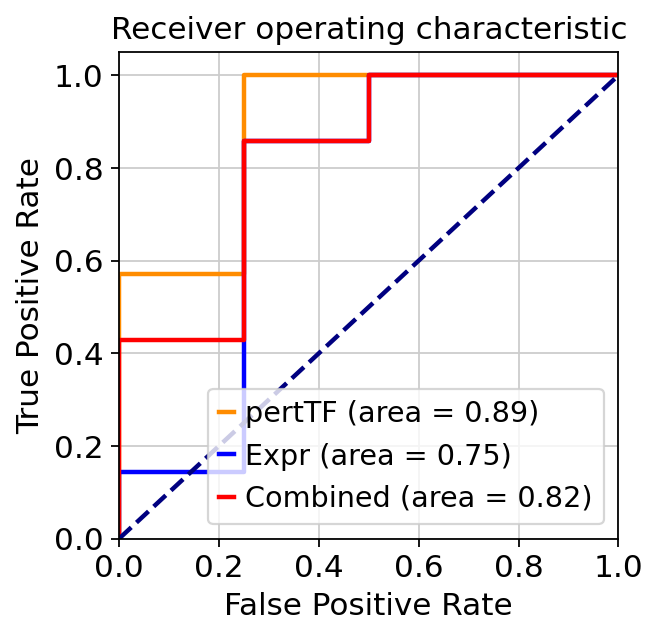

In [92]:

ranks = subset_fr_2['rank_percentile90'].values
y_true = subset_fr_2.index.isin(pool_screen_pos_list).astype(int)

subset_fr_2['rank_exp']=subset_fr_2['exp_mean'].rank(ascending=False, method='dense')
exp_ranks=subset_fr_2['rank_exp'].values
#exp_ranks=subset_fr['exp_mean'].values

subset_fr_2['rank_prod']=subset_fr_2['rank_percentile90']*subset_fr_2['rank_exp']
#prod_ranks=subset_fr['rank_prod'].values
subset_fr_2['rank_combined']=subset_fr_2['rank_prod'].rank(ascending=True, method='dense')
combined_ranks=subset_fr_2['rank_combined'].values

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, 1-ranks/np.max(ranks)) # Invert ranks for descending order
roc_auc = auc(fpr, tpr)

fpr2, tpr2, thresholds2 = roc_curve(y_true, 1-exp_ranks/np.max(exp_ranks)) # Invert ranks for descending order
roc_auc2 = auc(fpr2, tpr2)

fpr3, tpr3, thresholds3 = roc_curve(y_true, 1-combined_ranks/np.max(combined_ranks)) # Invert ranks for descending order
roc_auc3 = auc(fpr3, tpr3)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='pertTF (area = %0.2f)' % roc_auc)
plt.plot(fpr2, tpr2, color='blue', lw=2, label='Expr (area = %0.2f)' % roc_auc2)
plt.plot(fpr3, tpr3, color='red', lw=2, label='Combined (area = %0.2f)' % roc_auc3)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

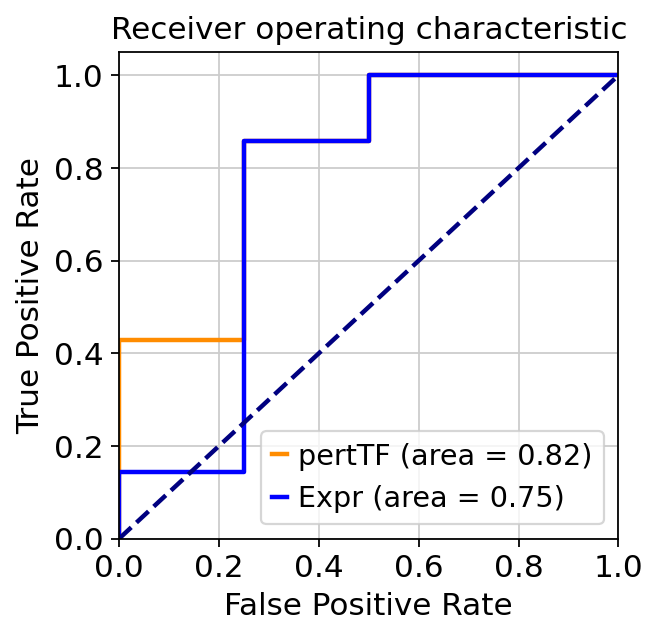

In [93]:
# Plot the ROC curve
plt.figure()
#plt.plot(fpr, tpr, color='darkorange', lw=2, label='pertTF (area = %0.2f)' % roc_auc)
plt.plot(fpr3, tpr3, color='darkorange', lw=2, label='pertTF (area = %0.2f)' % roc_auc3)
plt.plot(fpr2, tpr2, color='blue', lw=2, label='Expr (area = %0.2f)' % roc_auc2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

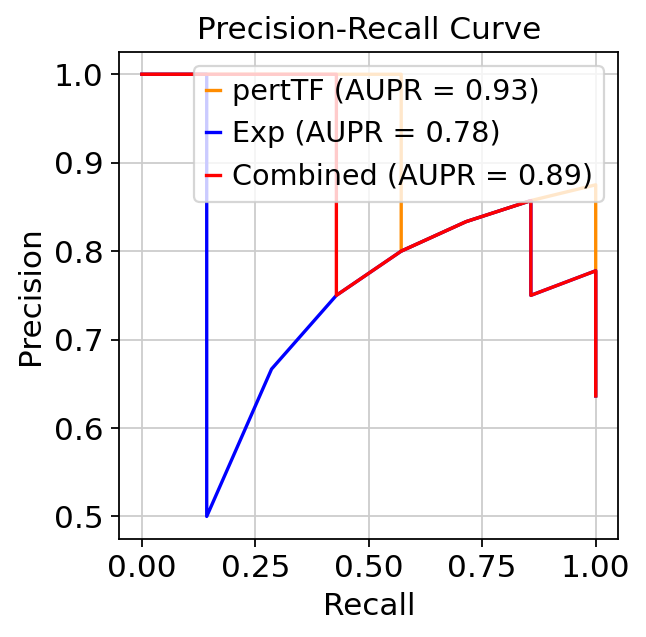

In [94]:



precision, recall, thresholds = precision_recall_curve(y_true, 1-ranks/np.max(ranks))  # Invert ranks for descending order
# Calculate AUC
pr_auc = auc(recall, precision)


precision2, recall2, thresholds2 = precision_recall_curve(y_true, 1-exp_ranks/np.max(exp_ranks))  # Invert ranks for descending order
# Calculate AUC
pr_auc2 = auc(recall2, precision2)


precision3, recall3, thresholds3 = precision_recall_curve(y_true, 1-combined_ranks/np.max(combined_ranks))  # Invert ranks for descending order
# Calculate AUC
pr_auc3 = auc(recall3, precision3)

# Plot the precision-recall curve
plt.figure()
plt.plot(recall, precision, color='darkorange',label=f'pertTF (AUPR = {pr_auc:.2f})')
plt.plot(recall2, precision2, color='blue',label=f'Exp (AUPR = {pr_auc2:.2f})')
plt.plot(recall3, precision3, color='red',label=f'Combined (AUPR = {pr_auc3:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='upper right')
plt.show()

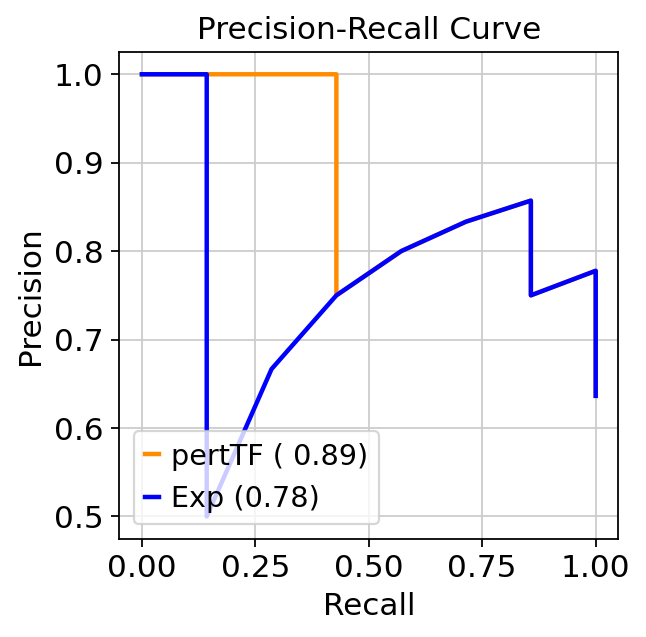

In [95]:

# Plot the precision-recall curve
plt.figure()
#plt.plot(recall, precision, color='darkorange',label=f'pertTF (AUPR = {pr_auc:.2f})')
plt.plot(recall3, precision3, color='darkorange',label=f'pertTF ( {pr_auc3:.2f})', linewidth=2)
plt.plot(recall2, precision2, color='blue',label=f'Exp ({pr_auc2:.2f})', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

In [96]:
subset_fr

,mean,median,count,percentile_90,rank,rank_median,rank_percentile90,plot_score
genotype_next,,,,,,,,
PDX1,0.999996,0.999997,105,0.999998,1.0,1.0,1.0,5.730986
RARA,0.996912,0.996905,94,0.996972,225.0,225.0,218.0,2.518859
MIXL1,0.996751,0.996746,86,0.996793,285.0,285.0,284.0,2.493954
GATA6,0.996624,0.996625,104,0.996671,330.0,328.0,330.0,2.477730
CCDC6,0.996614,0.996612,117,0.996657,335.0,336.0,333.0,2.475909
...,...,...,...,...,...,...,...,...
CA8,0.981822,0.981822,91,0.981858,9437.0,9438.0,9441.0,1.741310
TRIM38,0.980961,0.980944,101,0.981101,9530.0,9531.0,9526.0,1.723561
RNF111,0.979047,0.979046,98,0.979089,9691.0,9691.0,9693.0,1.679624


### plotting

### for plotting purpose only: regenerate anndata object for selected genes

In [97]:

cell_emb_all, perturb_f_all, cs_mat_res, adata_last_eva = generate_pert_embeddings(adata_test_gw_base,
                                                                       adata_test_wild_type,
                                                                       ['PDX1','WT', ],
                                                                       model, gene_ids, cell_type_to_index, genotype_to_index, vocab, config, device,
                                                                       n_expands_per_epoch= 2,
                                                                       n_epoch= 1,
                                                                       wt_pred_next_label =   dest_pert_label,
                                                                       )

pertTF - INFO - 2021 genes shared between model vocab's 2024 and anndata's 2021 genes
pertTF - INFO - Evaluating data using 2022 tokens for each cell


100%|██████████| 24/24 [00:00<00:00, 37.93it/s]


In [98]:
adata_test_gw_base.obs.genotype.value_counts()


,count
genotype,
WT,1187


In [99]:
adata_test_wild_type.obs.genotype.value_counts()

,count
genotype,
PDX1,669


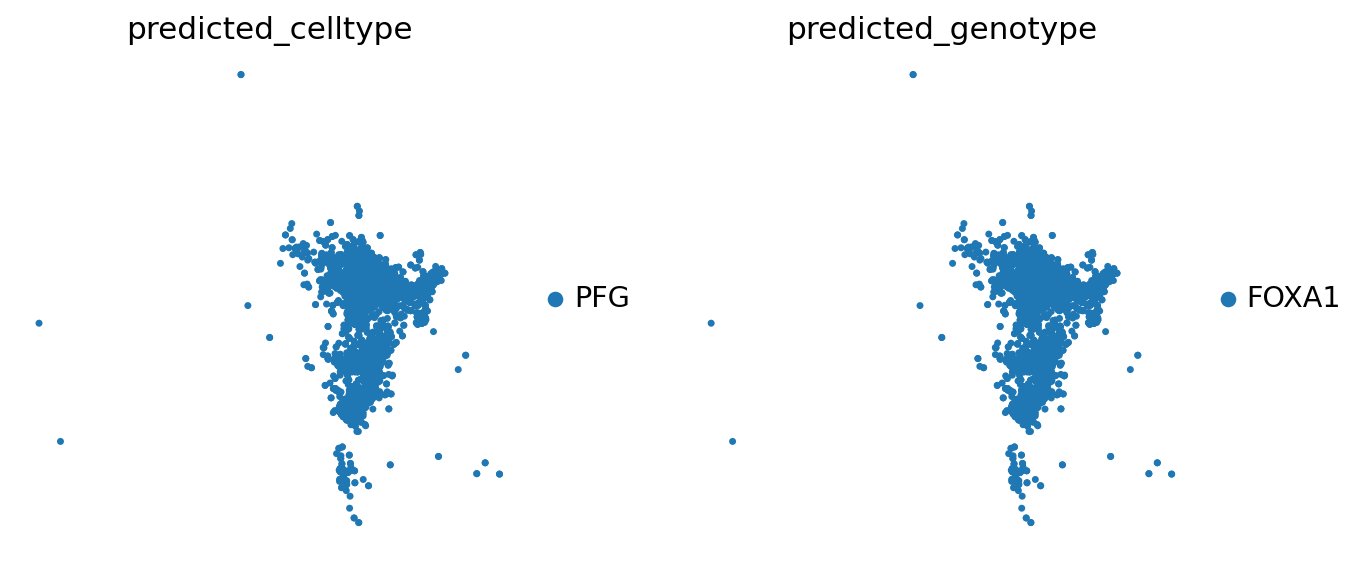

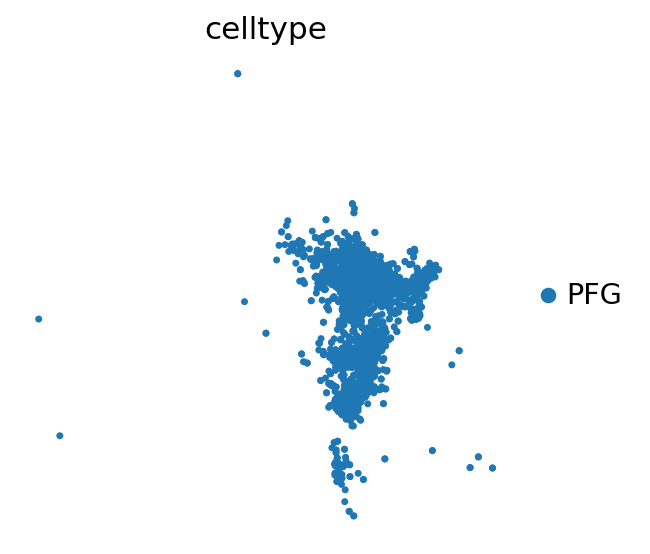

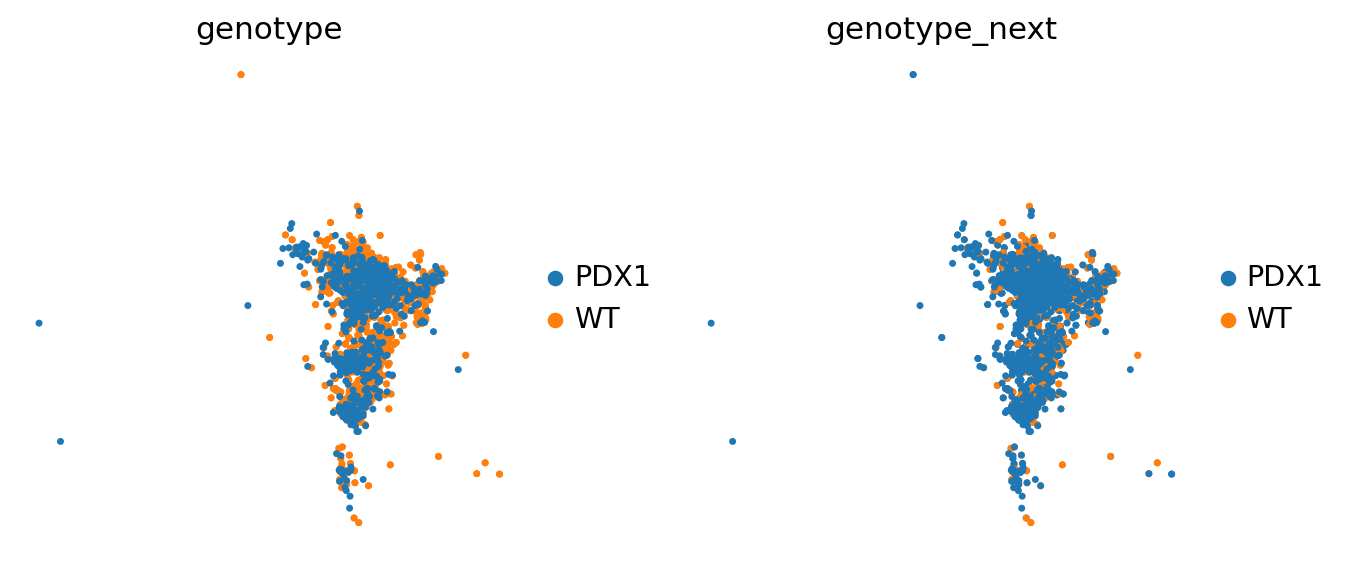

In [101]:
adata_eva = adata_last_eva
sc.pl.umap(adata_eva,
          color=["predicted_celltype", "predicted_genotype"],
          frameon=False,

          )
sc.pl.umap(adata_eva,
          color=[ "celltype", ],
          frameon=False,

          )

sc.pl.umap(adata_eva,
          color=[ "genotype","genotype_next"],
          frameon=False,

          )

In [102]:
#sc.pp.neighbors(adata, use_rep="X_scGPT_next")
randsel_ss=np.random.random(adata_eva.shape[0])

adata_eva_copy=adata_eva #[randsel_ss < 1]# .copy()
sc.pp.pca(adata_eva_copy)
sc.pp.neighbors(adata_eva_copy, use_rep="X_scGPT_next")

sc.tl.umap(adata_eva_copy, min_dist=0.5)


In [103]:
adata_eva_copy

AnnData object with n_obs × n_vars = 3043 × 2021
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'gene', 'sgrna', 'umi_count', 'nCount_sgRNA', 'nFeature_sgRNA', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'time_point', 'integrated_snn_res.0.5', 'S.Score', 'G2M.Score', 'Phase', 'time', 'celltype', 'celltype_individual', 'celltype_2', 'sub.cluster', 'genotype', 'is_in_training', 'genotype_next', 'predicted_genotype', 'genotype_id', 'predicted_celltype', 'celltype_id'
    uns: 'predicted_celltype_colors', 'predicted_genotype_colors', 'celltype_colors', 'genotype_colors', 'genotype_next_colors', 'pca', 'neighbors', 'umap'
    obsm: 'X_umap', 'X_scGPT', 'X_scGPT_next', 'X_pert_pred_probs', 'genotype_pred_probs', 'X_cls_pred_probs', 'celltype_pred_probs', 'X_pca'
    varm: 'PCs'
    layers: 'GPTin', 'X_binned'
    obsp: 'distances', 'connectivities'

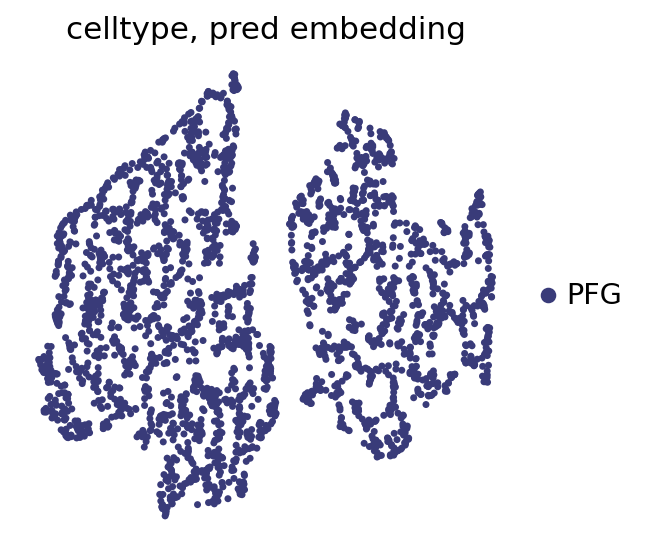

In [104]:
sc.pl.umap(adata_eva_copy, color=["celltype"],
    title=[f"celltype, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
    #legend_loc=None,
)

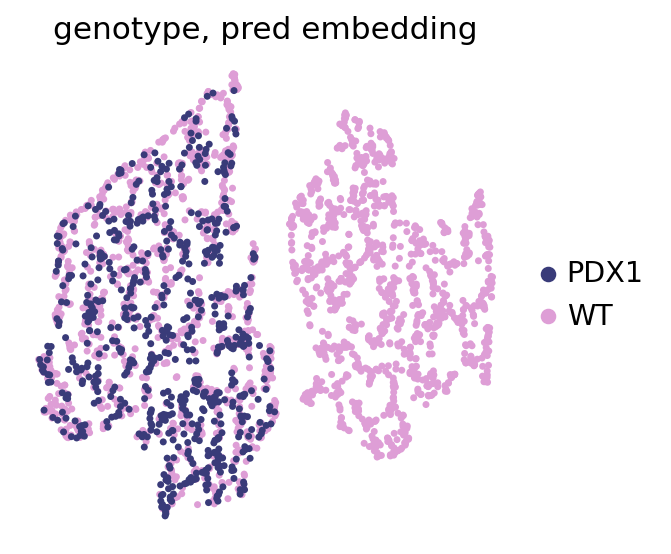

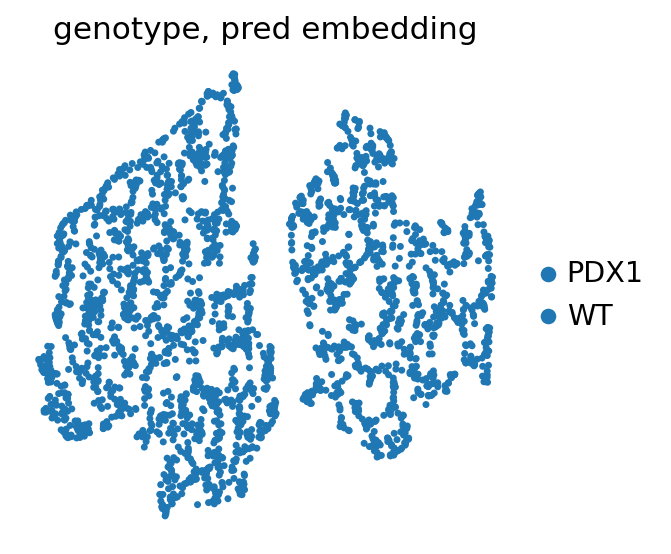

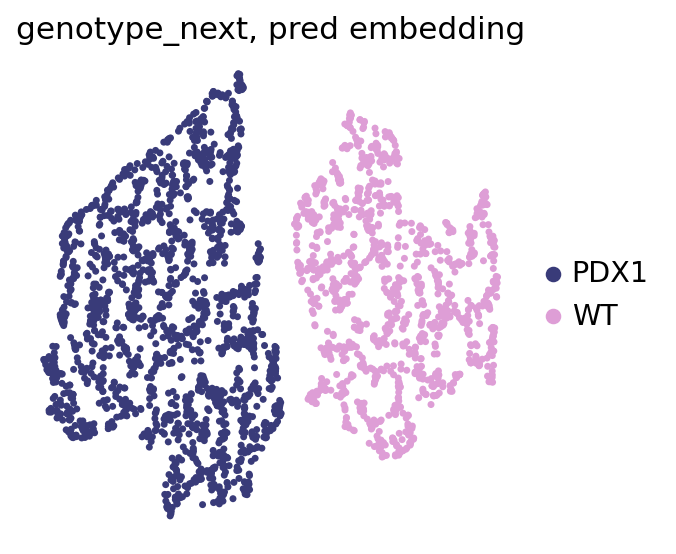

In [105]:

sc.pl.umap(adata_eva_copy, color=["genotype"],
    title=[f"genotype, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
    #legend_loc=None,
)

sc.pl.umap(adata_eva_copy, color=["genotype"],
    title=[f"genotype, pred embedding",],
    frameon=False,
    return_fig=False,
    #palette="tab20c",
    #palette=["tab20b","Set1"],
    #show=False,
    palette=generate_palette(30,cmap_name="tab20"),
    #legend_loc=None,
)
sc.pl.umap(adata_eva_copy, color=["genotype_next"],
    title=[f"genotype_next, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
    #legend_loc=None,
)

In [106]:
cm = plt.get_cmap('tab20b')
NUM_COLORS=30

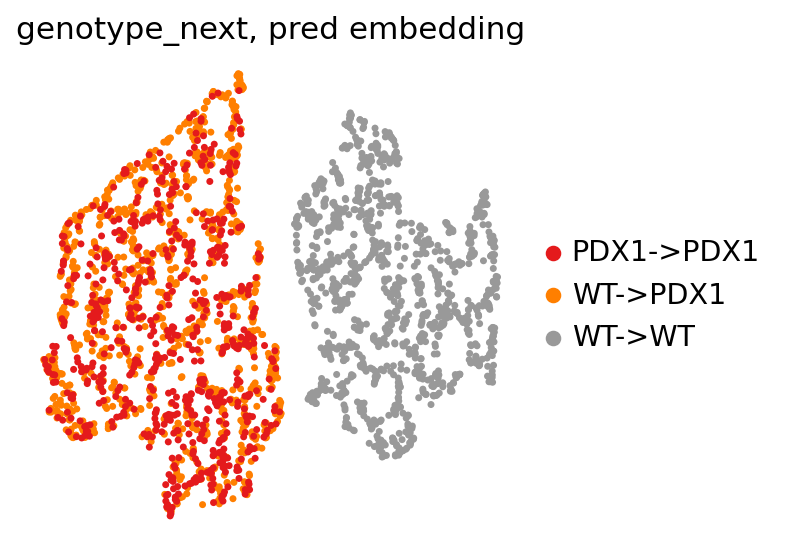

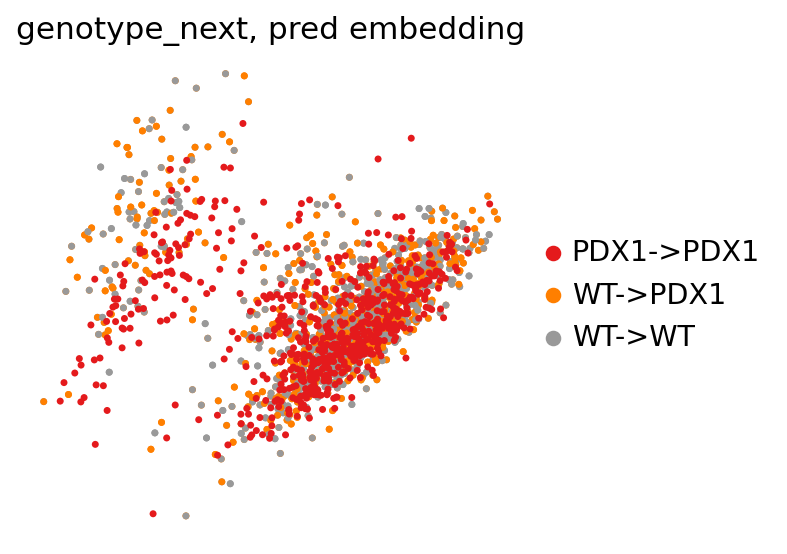

In [107]:
# prompt: concatenate both genotype and genotype_next columns of adata_eva_copy2.obs into a new column named "genotype_combined"

adata_eva_copy.obs["genotype_combined"] = adata_eva_copy.obs["genotype"].astype(str) + "->" + adata_eva_copy.obs["genotype_next"].astype(str)
sc.pl.umap(adata_eva_copy, color=["genotype_combined"],
    title=[f"genotype_next, pred embedding",],
    frameon=False,
    return_fig=False,
    #palette="tab20b",
    palette="Set1",
    #show=False,
    #palette=[cm(1.*i/NUM_COLORS) for i in range(NUM_COLORS)],
    #legend_loc=None,
)

sc.pl.pca(adata_eva_copy, color=["genotype_combined"],
    title=[f"genotype_next, pred embedding",],
    frameon=False,
    return_fig=False,
    #palette="tab20b",
    palette="Set1",
    #show=False,
    #palette=[cm(1.*i/NUM_COLORS) for i in range(NUM_COLORS)],
    #legend_loc=None,
)

